In [75]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/driver_race_features.csv"
)

print("shape:",df.shape)

shape: (2618, 22)


In [76]:
print(df.columns.to_list())
df.info()

['DriverNumber', 'Abbreviation', 'DriverId', 'TeamName', 'TeamId', 'FirstName', 'LastName', 'FullName', 'Position', 'ClassifiedPosition', 'GridPosition', 'Time', 'Status', 'Points', 'Laps', 'Year', 'Race', 'QualifyingPosition', 'Q1', 'Q2', 'Q3', 'BestQualifyingTime']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DriverNumber        2618 non-null   int64  
 1   Abbreviation        2618 non-null   object 
 2   DriverId            2618 non-null   object 
 3   TeamName            2618 non-null   object 
 4   TeamId              2618 non-null   object 
 5   FirstName           2618 non-null   object 
 6   LastName            2618 non-null   object 
 7   FullName            2618 non-null   object 
 8   Position            2615 non-null   float64
 9   ClassifiedPosition  2618 non-null   object 
 10  GridPosition        2615 non-nul

In [77]:
correlation = df[["GridPosition","Position"]].corr()
print(correlation)

              GridPosition  Position
GridPosition       1.00000   0.59836
Position           0.59836   1.00000


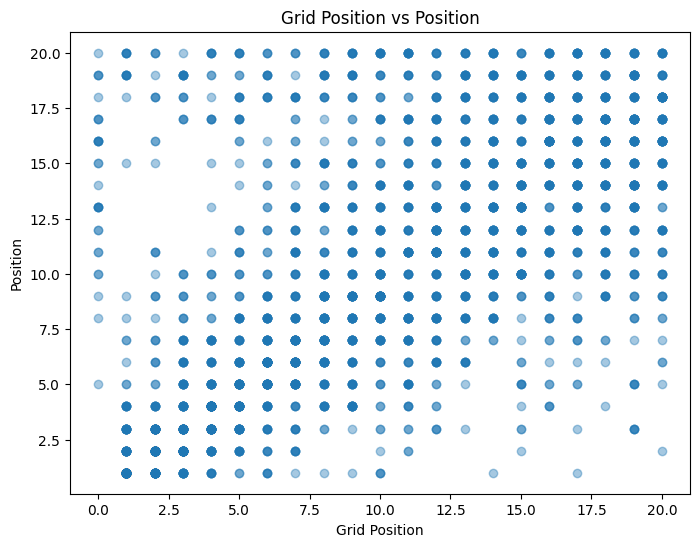

In [78]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["GridPosition"],
    df["Position"],
    alpha=0.4
)

plt.xlabel("Grid Position")
plt.ylabel("Position")
plt.title("Grid Position vs Position")

plt.show()

In [79]:
qualifying_correlation = df[
    ["QualifyingPosition", "Position"]
].corr()
print(qualifying_correlation)

                    QualifyingPosition  Position
QualifyingPosition            1.000000  0.639615
Position                      0.639615  1.000000


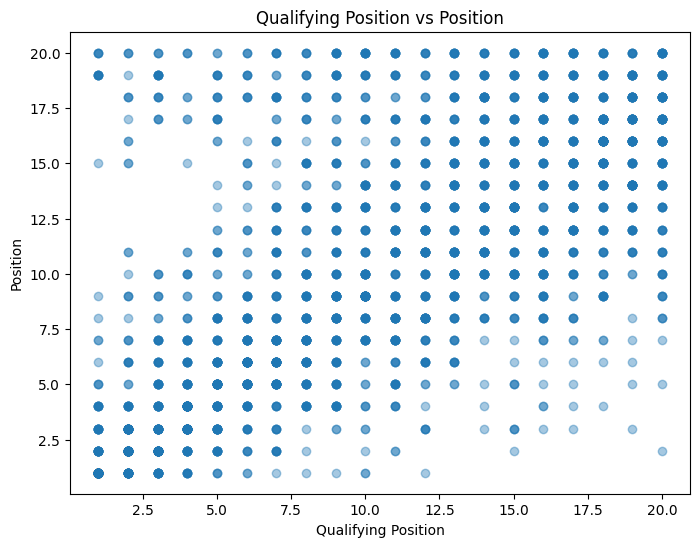

In [80]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["QualifyingPosition"],
    df["Position"],
    alpha=0.4
)

plt.xlabel("Qualifying Position")
plt.ylabel("Position")
plt.title("Qualifying Position vs Position")
plt.show()

In [81]:
df["PositionGain"] = (df["QualifyingPosition"]-df["Position"])
print(
    df[
        [
            "FullName",
            "QualifyingPosition",
            "Position",
            "PositionGain"
        ]
    ].head(10)
)

          FullName  QualifyingPosition  Position  PositionGain
0   Max Verstappen                 4.0       1.0           3.0
1   Lewis Hamilton                 2.0       2.0           0.0
2  Valtteri Bottas                 1.0       3.0          -2.0
3  Charles Leclerc                 8.0       4.0           4.0
4  Alexander Albon                 9.0       5.0           4.0
5     Lance Stroll                 6.0       6.0           0.0
6  Nico Hulkenberg                 3.0       7.0          -4.0
7     Esteban Ocon                11.0       8.0           3.0
8     Lando Norris                10.0       9.0           1.0
9     Daniil Kvyat                16.0      10.0           6.0


In [82]:
biggest_gains = df.sort_values(
    "PositionGain",
    ascending=False
).head(10)

print("Biggest position gains:")
print(
    biggest_gains[
        [
            "Year",
            "Race",
            "FullName",
            "QualifyingPosition",
            "Position",
            "PositionGain"
        ]
    ]
)

biggest_losses = df.sort_values(
    "PositionGain",
    ascending=True
).head(10)

print("Biggest position losses:")
print(
    biggest_losses[
        [
            "Year",
            "Race",
            "FullName",
            "QualifyingPosition",
            "Position",
            "PositionGain"
        ]
    ]
)

Biggest position gains:
      Year                      Race         FullName  QualifyingPosition  \
641   2021        russian grand prix   Max Verstappen                20.0   
2261  2025        british grand prix  Nico Hulkenberg                19.0   
1244  2023     australian grand prix     Sergio Perez                20.0   
1484  2023    mexico city grand prix     Lando Norris                19.0   
2421  2025      las vegas grand prix   Kimi Antonelli                17.0   
1663  2024      abu dhabi grand prix   Lewis Hamilton                18.0   
1463  2023      las vegas grand prix     Esteban Ocon                17.0   
1561  2023  saudi arabian grand prix   Max Verstappen                15.0   
2325  2025          dutch grand prix     Lance Stroll                20.0   
2580  2025      são paulo grand prix   Max Verstappen                16.0   

      Position  PositionGain  
641        2.0          18.0  
2261       3.0          16.0  
1244       5.0          15.0  
1484

In [83]:
print("Position Gain Statistics:",df["PositionGain"].describe())
print("\nAverage position gain:",df["PositionGain"].mean())
print("\nMedian position gain:",df["PositionGain"].median())

Position Gain Statistics: count    2593.000000
mean       -0.008484
std         4.882248
min       -19.000000
25%        -2.000000
50%         0.000000
75%         3.000000
max        18.000000
Name: PositionGain, dtype: float64

Average position gain: -0.008484381025838797

Median position gain: 0.0


In [84]:
extreme_changes = df[
    df["PositionGain"].abs() >= 10
][
    [
        "Year",
        "Race",
        "FullName",
        "QualifyingPosition",
        "Position",
        "PositionGain",
        "Status"
    ]
].sort_values(
    "PositionGain"
)

print(extreme_changes.to_string(index=False))

 Year                      Race              FullName  QualifyingPosition  Position  PositionGain           Status
 2021         monaco grand prix       Charles Leclerc                 1.0      20.0         -19.0       Driveshaft
 2023  united states grand prix       Charles Leclerc                 1.0      20.0         -19.0     Disqualified
 2022        spanish grand prix       Charles Leclerc                 1.0      20.0         -19.0            Turbo
 2022  united states grand prix          Carlos Sainz                 1.0      20.0         -19.0 Collision damage
 2022         french grand prix       Charles Leclerc                 1.0      19.0         -18.0         Accident
 2020          eifel grand prix       Valtteri Bottas                 1.0      19.0         -18.0       Power Unit
 2022     azerbaijan grand prix       Charles Leclerc                 1.0      19.0         -18.0       Power Unit
 2021        british grand prix        Max Verstappen                 2.0      2

In [85]:
status_position_gain = (
    extreme_changes
    .groupby("Status")["PositionGain"]
    .agg(["count", "mean", "min", "max"])
    .sort_values("count", ascending=False)
)

print(status_position_gain)

                  count       mean   min   max
Status                                        
Finished             47   9.723404 -14.0  18.0
Retired              42 -12.666667 -18.0 -10.0
Collision            18 -13.055556 -18.0 -10.0
Disqualified          8 -14.625000 -19.0 -10.0
Lapped                7  -6.714286 -18.0  11.0
Power Unit            6 -14.166667 -18.0 -10.0
Engine                6 -11.666667 -13.0 -10.0
Accident              6 -14.666667 -18.0 -10.0
Collision damage      5 -14.200000 -19.0 -10.0
Gearbox               3 -11.666667 -14.0 -10.0
+1 Lap                3 -11.000000 -12.0 -10.0
Suspension            3 -11.666667 -13.0 -11.0
Electronics           2 -14.000000 -17.0 -11.0
Hydraulics            2 -14.500000 -16.0 -13.0
Undertray             2 -11.000000 -12.0 -10.0
Did not start         2 -14.500000 -18.0 -11.0
Fuel pressure         2 -15.500000 -17.0 -14.0
Fuel leak             1 -16.000000 -16.0 -16.0
Differential          1 -11.000000 -11.0 -11.0
Exhaust      

In [86]:
status_overall = (
    df
    .groupby("Status")["PositionGain"]
    .agg(["count", "mean", "min", "max"])
    .sort_values("count", ascending=False)
)

print(status_overall)

                  count       mean   min   max
Status                                        
Finished           1597   1.366312 -14.0  18.0
+1 Lap              294   0.666667 -12.0   9.0
Lapped              288   0.093750 -18.0  11.0
Retired             156  -5.955128 -18.0   4.0
Collision            42  -7.595238 -18.0   5.0
+2 Laps              41  -0.243902 -14.0   6.0
Accident             23  -5.043478 -18.0   2.0
Collision damage     22  -4.954545 -19.0   3.0
Power Unit           13  -8.000000 -18.0   4.0
Engine               13  -7.076923 -13.0   2.0
Gearbox              12  -6.083333 -14.0  -1.0
Disqualified         11 -11.454545 -19.0  -1.0
Did not start         9  -7.111111 -18.0   0.0
Brakes                7  -3.285714 -10.0  -1.0
+3 Laps               5   1.000000  -1.0   2.0
Hydraulics            5  -7.400000 -16.0   0.0
Suspension            4  -8.500000 -13.0   1.0
Electronics           3 -12.000000 -17.0  -8.0
Undertray             3  -7.333333 -12.0   0.0
Puncture     

In [87]:
yearly_position_gain = (
    df
    .groupby("Year")["PositionGain"]
    .agg(["count", "mean", "median", "std"])
)

print(yearly_position_gain)

      count      mean  median       std
Year                                   
2020    340  0.000000     1.0  5.116345
2021    438 -0.004566     0.0  4.831246
2022    439  0.013667     1.0  5.244244
2023    439 -0.011390     0.0  5.189325
2024    459 -0.052288     0.0  4.149169
2025    478  0.006276     0.0  4.798450


In [88]:
qualifying_time_correlation = df[
    ["BestQualifyingTime", "Position"]
].corr()

print(qualifying_time_correlation)

                    BestQualifyingTime  Position
BestQualifyingTime            1.000000  0.054554
Position                      0.054554  1.000000


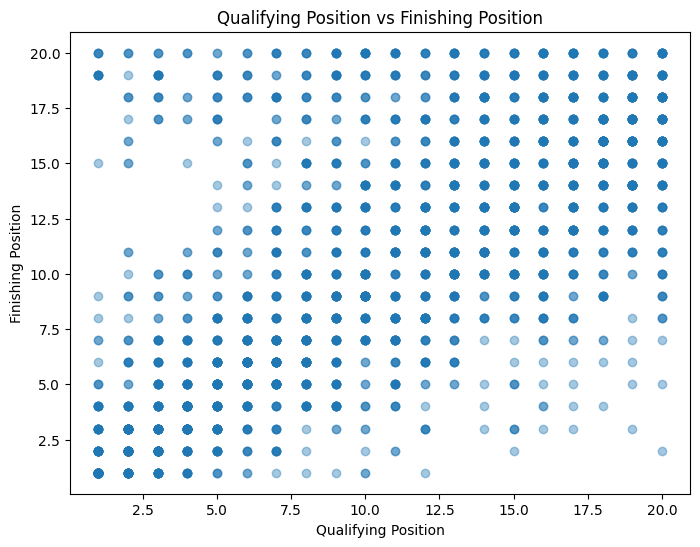

In [89]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["QualifyingPosition"],
    df["Position"],
    alpha=0.4
)

plt.xlabel("Qualifying Position")
plt.ylabel("Finishing Position")
plt.title("Qualifying Position vs Finishing Position")

plt.show()

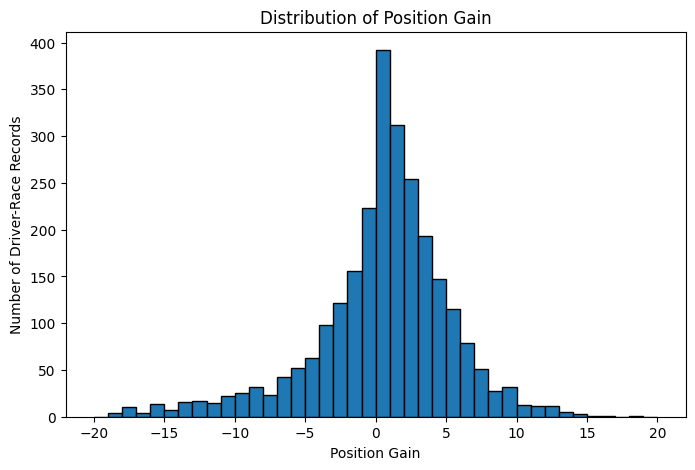

In [90]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["PositionGain"].dropna(),
    bins=range(-20, 21),
    edgecolor="black"
)



plt.xlabel("Position Gain")
plt.ylabel("Number of Driver-Race Records")
plt.title("Distribution of Position Gain")

plt.show()

In [91]:
driver_performance = (
    df
    .groupby("FullName")["PositionGain"]
    .agg(
        Races="count",
        AverageGain="mean",
        MedianGain="median",
        StdGain="std"
    )
    .sort_values("AverageGain", ascending=False)
)

print(driver_performance.head(15))

                       Races  AverageGain  MedianGain   StdGain
FullName                                                       
Andrea Kimi Antonelli      1    12.000000        12.0       NaN
Robert Kubica              2     4.000000         4.0  1.414214
Kimi Räikkönen            37     3.027027         4.0  3.370513
Oliver Bearman            27     2.037037         2.0  4.686162
Nicholas Latifi           61     2.032787         2.0  3.346477
Jack Aitken                1     2.000000         2.0       NaN
Nikita Mazepin            21     1.809524         2.0  1.631534
Romain Grosjean           15     1.666667         2.0  2.870208
Antonio Giovinazzi        39     1.512821         1.0  3.858496
Pietro Fittipaldi          2     1.500000         1.5  2.121320
Guanyu Zhou               67     1.492537         2.0  3.944206
Franco Colapinto          27     1.333333         0.0  3.063432
Nyck De Vries             11     1.272727         0.0  2.412091
Lance Stroll             127     1.22834

In [92]:
driver_performance_20 = (
    driver_performance[
        driver_performance["Races"] >= 20
    ]
    .sort_values("AverageGain", ascending=False)
)

print(driver_performance_20)

                    Races  AverageGain  MedianGain   StdGain
FullName                                                    
Kimi Räikkönen         37     3.027027         4.0  3.370513
Oliver Bearman         27     2.037037         2.0  4.686162
Nicholas Latifi        61     2.032787         2.0  3.346477
Nikita Mazepin         21     1.809524         2.0  1.631534
Antonio Giovinazzi     39     1.512821         1.0  3.858496
Guanyu Zhou            67     1.492537         2.0  3.944206
Franco Colapinto       27     1.333333         0.0  3.063432
Lance Stroll          127     1.228346         2.0  4.915458
Sebastian Vettel       59     1.084746         1.0  4.356082
Logan Sargeant         35     1.028571         2.0  4.176163
Mick Schumacher        42     0.833333         1.0  4.321905
Esteban Ocon          129     0.821705         1.0  4.478158
Daniel Ricciardo       85     0.247059         1.0  4.180185
Lewis Hamilton        129     0.240310         0.0  4.966726
Sergio Perez          10

In [93]:
laps = pd.read_csv(
    "../data/raw/laps/british_gp_2025.csv"
)

print("Laps dataset loaded!")
print("Shape:", laps.shape)

print("\nColumns:")
print(laps.columns.tolist())

print("\nFirst 10 rows:")
print(
    laps[
        [
            "Driver",
            "LapNumber",
            "LapTime",
            "Compound",
            "TyreLife",
            "Stint",
            "PitInTime",
            "PitOutTime",
            "Position"
        ]
    ].head(10)
)

Laps dataset loaded!
Shape: (825, 31)

Columns:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']

First 10 rows:
  Driver  LapNumber                 LapTime      Compound  TyreLife  Stint  \
0    VER        1.0  0 days 00:01:45.820000  INTERMEDIATE       1.0    1.0   
1    VER        2.0  0 days 00:02:15.598000  INTERMEDIATE       2.0    1.0   
2    VER        3.0  0 days 00:02:17.357000  INTERMEDIATE       3.0    1.0   
3    VER        4.0  0 days 00:01:45.568000  INTERMEDIATE       4.0    1.0   
4    VER        5.0  0 days 00:01:44.809000  INTERMEDIATE       5.0    1.0   
5    VER        6.0  0 days 00:02:1

In [94]:
compound_summary = (
    laps
    .groupby("Compound")
    .agg(
        Laps=("LapNumber", "count"),
        Drivers=("Driver", "nunique")
    )
    .sort_values("Laps", ascending=False)
)

print(compound_summary)

              Laps  Drivers
Compound                   
INTERMEDIATE   608       18
MEDIUM         140       14
HARD            41        3
SOFT            36        3


In [95]:
laps["LapTime"] = pd.to_timedelta(
    laps["LapTime"],
    errors="coerce"
)

print(laps["LapTime"].dtype)

compound_pace_seconds = (
    laps
    .groupby("Compound")["LapTime"]
    .mean()
    .dt.total_seconds()
    .sort_values()
)

print(compound_pace_seconds)

timedelta64[ns]
Compound
SOFT             98.059056
MEDIUM          100.465568
INTERMEDIATE    111.068341
HARD            111.371700
Name: LapTime, dtype: float64


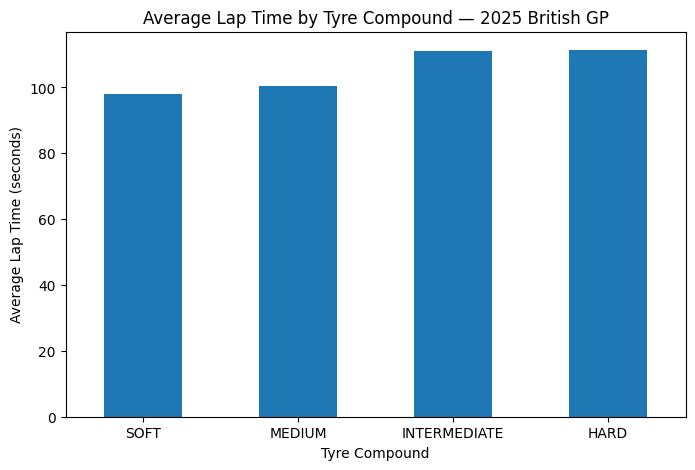

In [96]:
plt.figure(figsize=(8, 5))

compound_pace_seconds.plot(kind="bar")

plt.xlabel("Tyre Compound")
plt.ylabel("Average Lap Time (seconds)")
plt.title("Average Lap Time by Tyre Compound — 2025 British GP")
plt.xticks(rotation=0)

plt.show()

In [97]:
stint_summary = (
    laps
    .groupby(["Driver", "Stint", "Compound"])
    .agg(
        StartLap=("LapNumber", "min"),
        EndLap=("LapNumber", "max"),
        Laps=("LapNumber", "count")
    )
    .reset_index()
)

print(stint_summary.head(20))

   Driver  Stint      Compound  StartLap  EndLap  Laps
0     ALB    1.0  INTERMEDIATE       1.0    12.0    12
1     ALB    2.0  INTERMEDIATE      13.0    42.0    30
2     ALB    3.0        MEDIUM      43.0    52.0    10
3     ALO    1.0  INTERMEDIATE       1.0    11.0    11
4     ALO    2.0  INTERMEDIATE      12.0    37.0    26
5     ALO    3.0        MEDIUM      38.0    52.0    15
6     ANT    1.0  INTERMEDIATE       1.0     2.0     2
7     ANT    2.0          HARD       3.0     9.0     7
8     ANT    3.0  INTERMEDIATE      10.0    20.0    11
9     ANT    4.0  INTERMEDIATE      21.0    23.0     3
10    BEA    1.0          HARD       1.0    10.0    10
11    BEA    2.0  INTERMEDIATE      11.0    41.0    31
12    BEA    3.0        MEDIUM      42.0    52.0    11
13    BOR    1.0        MEDIUM       1.0     4.0     4
14    GAS    1.0  INTERMEDIATE       1.0    11.0    11
15    GAS    2.0  INTERMEDIATE      12.0    41.0    30
16    GAS    3.0        MEDIUM      42.0    52.0    11
17    HAD 

In [98]:
stint_compound_summary = (
    stint_summary
    .groupby("Compound")["Laps"]
    .agg(
        Stints="count",
        AverageStintLength="mean",
        MedianStintLength="median",
        LongestStint="max"
    )
    .sort_values("AverageStintLength", ascending=False)
)

print(stint_compound_summary)

              Stints  AverageStintLength  MedianStintLength  LongestStint
Compound                                                                 
INTERMEDIATE      32               19.00               15.0            33
HARD               4               10.25               10.0            14
MEDIUM            14               10.00               10.0            15
SOFT               4                9.00               10.5            11


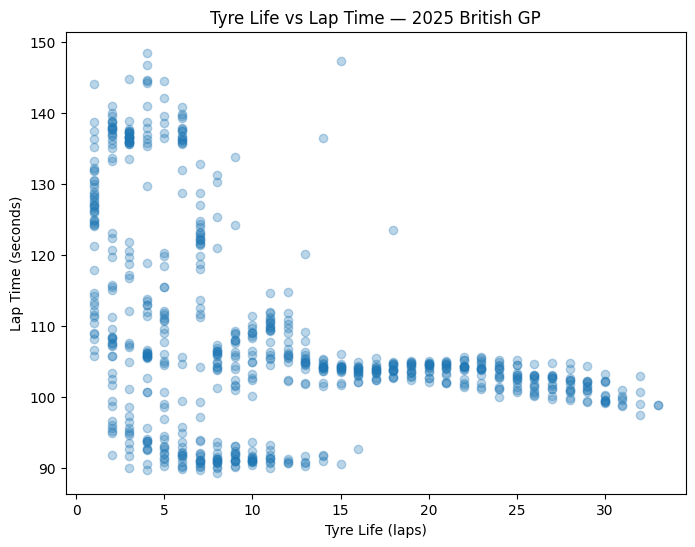

In [99]:
plt.figure(figsize=(8, 6))

plt.scatter(
    laps["TyreLife"],
    laps["LapTime"].dt.total_seconds(),
    alpha=0.3
)

plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Tyre Life vs Lap Time — 2025 British GP")

plt.show()

In [100]:
tyre_life_correlation = (
    laps
    .groupby("Compound")
    .apply(
        lambda group: group["TyreLife"].corr(
            group["LapTime"].dt.total_seconds()
        )
    )
)

print(tyre_life_correlation)

Compound
HARD           -0.724716
INTERMEDIATE   -0.680228
MEDIUM         -0.546734
SOFT           -0.608659
dtype: float64


C:\Users\chris\AppData\Local\Temp\ipykernel_266700\2152989003.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [101]:
weather = pd.read_csv(
    "../data/raw/weather/british_gp_2025.csv"
)

print(weather["Rainfall"].value_counts())
print(
    weather[
        ["Time", "Rainfall", "TrackTemp"]
    ].head(20)
)

Rainfall
False    127
True      28
Name: count, dtype: int64
                      Time  Rainfall  TrackTemp
0   0 days 00:00:19.723000     False       24.2
1   0 days 00:01:19.675000     False       24.6
2   0 days 00:02:19.683000     False       24.6
3   0 days 00:03:19.685000     False       24.1
4   0 days 00:04:19.683000     False       23.9
5   0 days 00:05:19.685000     False       24.0
6   0 days 00:06:19.669000     False       24.2
7   0 days 00:07:19.684000     False       25.4
8   0 days 00:08:19.685000     False       25.9
9   0 days 00:09:19.679000     False       26.0
10  0 days 00:10:19.679000     False       26.0
11  0 days 00:11:19.686000     False       24.9
12  0 days 00:12:19.684000     False       24.6
13  0 days 00:13:19.687000     False       24.0
14  0 days 00:14:19.689000      True       24.0
15  0 days 00:15:19.688000      True       23.9
16  0 days 00:16:19.738000      True       22.6
17  0 days 00:17:19.694000      True       22.3
18  0 days 00:18:19.689000 

In [102]:
weather["Time"] = pd.to_timedelta(
    weather["Time"],
    errors="coerce"
)

print(weather["Time"].dtype)

timedelta64[ns]


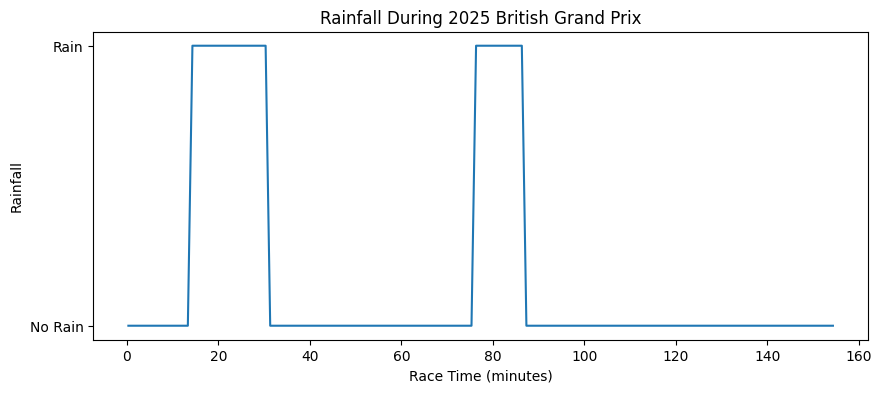

In [103]:
plt.figure(figsize=(10, 4))

plt.plot(
    weather["Time"].dt.total_seconds() / 60,
    weather["Rainfall"].astype(int)
)

plt.xlabel("Race Time (minutes)")
plt.ylabel("Rainfall")
plt.title("Rainfall During 2025 British Grand Prix")

plt.yticks([0, 1], ["No Rain", "Rain"])

plt.show()

In [104]:
pit_stop_summary = (
    laps[
        laps["PitInTime"].notna()
    ]
    .groupby("Driver")
    .size()
    .sort_values(ascending=False)
)

print(pit_stop_summary)

Driver
ANT    4
STR    3
ALB    2
BEA    2
ALO    2
HAM    2
HUL    2
LEC    2
GAS    2
RUS    2
NOR    2
PIA    2
OCO    2
TSU    2
SAI    2
VER    2
HAD    1
dtype: int64


In [105]:
pit_timing = (
    laps[
        laps["PitInTime"].notna()
    ][
        [
            "Driver",
            "LapNumber",
            "Stint",
            "Compound"
        ]
    ]
    .sort_values(
        ["Driver", "LapNumber"]
    )
)

print(pit_timing.to_string(index=False))

Driver  LapNumber  Stint     Compound
   ALB       12.0    1.0 INTERMEDIATE
   ALB       42.0    2.0 INTERMEDIATE
   ALO       11.0    1.0 INTERMEDIATE
   ALO       37.0    2.0 INTERMEDIATE
   ANT        2.0    1.0 INTERMEDIATE
   ANT        9.0    2.0         HARD
   ANT       20.0    3.0 INTERMEDIATE
   ANT       23.0    4.0 INTERMEDIATE
   BEA       10.0    1.0         HARD
   BEA       41.0    2.0 INTERMEDIATE
   GAS       11.0    1.0 INTERMEDIATE
   GAS       41.0    2.0 INTERMEDIATE
   HAD       10.0    1.0       MEDIUM
   HAM       11.0    1.0 INTERMEDIATE
   HAM       41.0    2.0 INTERMEDIATE
   HUL        9.0    1.0 INTERMEDIATE
   HUL       42.0    2.0 INTERMEDIATE
   LEC       10.0    1.0       MEDIUM
   LEC       42.0    2.0 INTERMEDIATE
   NOR       11.0    1.0 INTERMEDIATE
   NOR       44.0    2.0 INTERMEDIATE
   OCO       18.0    1.0 INTERMEDIATE
   OCO       42.0    2.0 INTERMEDIATE
   PIA       11.0    1.0 INTERMEDIATE
   PIA       43.0    2.0 INTERMEDIATE
   RUS      

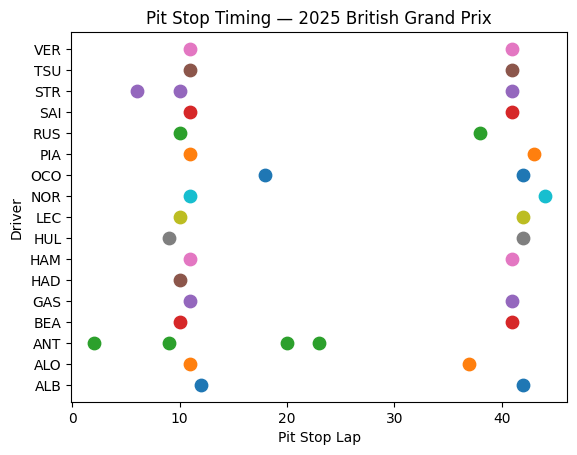

In [106]:

for driver in pit_timing["Driver"].unique():
    driver_stops = pit_timing[
        pit_timing["Driver"] == driver
    ]

    plt.scatter(
        driver_stops["LapNumber"],
        [driver] * len(driver_stops),
        s=80
    )

plt.xlabel("Pit Stop Lap")
plt.ylabel("Driver")
plt.title("Pit Stop Timing — 2025 British Grand Prix")

plt.show()

In [107]:
pit_time_check = laps[
    laps["PitInTime"].notna() |
    laps["PitOutTime"].notna()
][
    [
        "Driver",
        "LapNumber",
        "PitInTime",
        "PitOutTime"
    ]
]

print(
    pit_time_check.to_string(index=False)
)

pit_stops = laps[
    laps["PitInTime"].notna()
].copy()

pit_stops["PitInTime"] = pd.to_timedelta(
    pit_stops["PitInTime"],
    errors="coerce"
)

pit_stops["PitOutTime"] = pd.to_timedelta(
    pit_stops["PitOutTime"],
    errors="coerce"
)

pit_stops["PitStopDuration"] = (
    pit_stops["PitOutTime"]
    - pit_stops["PitInTime"]
)

pit_stops["PitStopDurationSeconds"] = (
    pit_stops["PitStopDuration"]
    .dt.total_seconds()
)

print(
    pit_stops[
        [
            "Driver",
            "LapNumber",
            "Compound",
            "PitStopDurationSeconds"
        ]
    ].to_string(index=False)
)

Driver  LapNumber              PitInTime             PitOutTime
   VER       11.0 0 days 01:17:23.948000                    NaN
   VER       12.0                    NaN 0 days 01:17:52.088000
   VER       41.0 0 days 02:16:41.355000                    NaN
   VER       42.0                    NaN 0 days 02:17:11.002000
   GAS       11.0 0 days 01:17:34.025000                    NaN
   GAS       12.0                    NaN 0 days 01:18:02.828000
   GAS       41.0 0 days 02:16:43.664000                    NaN
   GAS       42.0                    NaN 0 days 02:17:12.127000
   ANT        2.0 0 days 01:00:08.067000                    NaN
   ANT        3.0                    NaN 0 days 01:00:36.856000
   ANT        9.0 0 days 01:14:14.745000                    NaN
   ANT       10.0                    NaN 0 days 01:14:43.467000
   ANT       20.0 0 days 01:39:25.387000                    NaN
   ANT       21.0                    NaN 0 days 01:39:55.175000
   ANT       23.0 0 days 01:46:02.187000

In [108]:
ver_laps = laps[
    laps["Driver"] == "VER"
].copy()


print(
    ver_laps[
        [
            "LapNumber",
            "LapTime",
            "Compound",
            "TyreLife",
            "Position"
        ]
    ].head(20)
)



    LapNumber                LapTime      Compound  TyreLife  Position
0         1.0 0 days 00:01:45.820000  INTERMEDIATE       1.0       1.0
1         2.0 0 days 00:02:15.598000  INTERMEDIATE       2.0       1.0
2         3.0 0 days 00:02:17.357000  INTERMEDIATE       3.0       1.0
3         4.0 0 days 00:01:45.568000  INTERMEDIATE       4.0       1.0
4         5.0 0 days 00:01:44.809000  INTERMEDIATE       5.0       1.0
5         6.0 0 days 00:02:19.789000  INTERMEDIATE       6.0       1.0
6         7.0 0 days 00:02:02.547000  INTERMEDIATE       7.0       1.0
7         8.0 0 days 00:01:45.834000  INTERMEDIATE       8.0       2.0
8         9.0 0 days 00:01:46.326000  INTERMEDIATE       9.0       2.0
9        10.0 0 days 00:01:46.432000  INTERMEDIATE      10.0       2.0
10       11.0 0 days 00:01:50.497000  INTERMEDIATE      11.0       3.0
11       12.0 0 days 00:02:06.914000  INTERMEDIATE       1.0       2.0
12       13.0 0 days 00:01:51.224000  INTERMEDIATE       2.0       2.0
13    

In [109]:
ver_laps["LapTimeSeconds"] = (
    ver_laps["LapTime"]
    .dt.total_seconds()
)

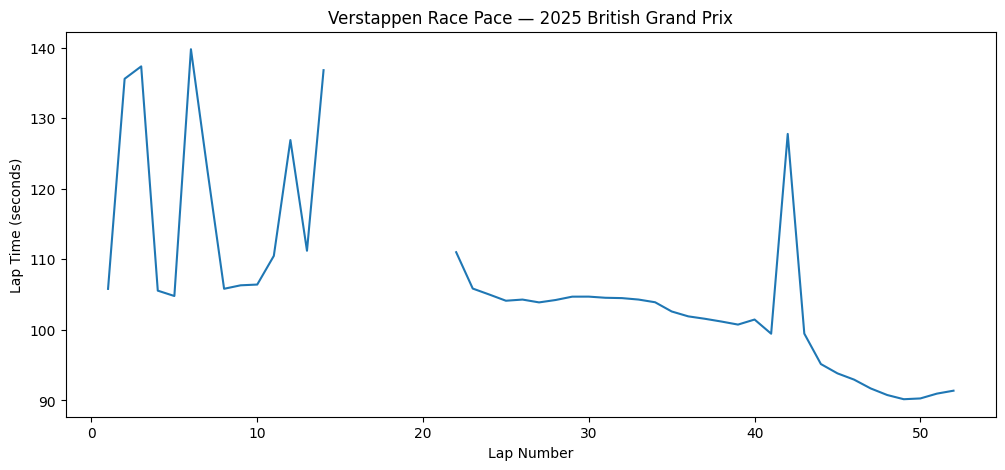

In [110]:
plt.figure(figsize=(12, 5))

plt.plot(
    ver_laps["LapNumber"],
    ver_laps["LapTimeSeconds"]
)

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Verstappen Race Pace — 2025 British Grand Prix")

plt.show()

In [111]:
print(
    ver_laps[
        ver_laps["LapTimeSeconds"].isna()
    ][
        [
            "LapNumber",
            "Compound",
            "TyreLife",
            "Position"
        ]
    ]
)

    LapNumber      Compound  TyreLife  Position
14       15.0  INTERMEDIATE       4.0       2.0
15       16.0  INTERMEDIATE       5.0       2.0
16       17.0  INTERMEDIATE       6.0       2.0
18       19.0  INTERMEDIATE       8.0       2.0
19       20.0  INTERMEDIATE       9.0       2.0
20       21.0  INTERMEDIATE      10.0      10.0


In [112]:
print(
    ver_laps[
        ver_laps["LapNumber"].between(14, 22)
    ][
        [
            "LapNumber",
            "LapTime",
            "Compound",
            "TyreLife",
            "Position",
            "TrackStatus",
            "Deleted",
            "DeletedReason",
            "IsAccurate",
            "FastF1Generated"
        ]
    ].to_string(index=False)
)

 LapNumber                LapTime     Compound  TyreLife  Position  TrackStatus  Deleted DeletedReason  IsAccurate  FastF1Generated
      14.0 0 days 00:02:16.820000 INTERMEDIATE       3.0       2.0           14    False           NaN       False            False
      15.0                    NaT INTERMEDIATE       4.0       2.0            4    False           NaN       False            False
      16.0                    NaT INTERMEDIATE       5.0       2.0            4    False           NaN       False            False
      17.0                    NaT INTERMEDIATE       6.0       2.0           41    False           NaN       False            False
      18.0 0 days 00:01:58.665000 INTERMEDIATE       7.0       2.0          124    False           NaN       False            False
      19.0                    NaT INTERMEDIATE       8.0       2.0            4    False           NaN       False            False
      20.0                    NaT INTERMEDIATE       9.0       2.0          

In [113]:
ver_pace = ver_laps[
    ver_laps["IsAccurate"] == True
].copy()

ver_pace["LapTimeSeconds"] = (
    ver_pace["LapTime"]
    .dt.total_seconds()
)

print("Accurate laps:", len(ver_pace))

print(
    ver_pace[
        [
            "LapNumber",
            "LapTimeSeconds",
            "Compound",
            "TyreLife",
            "Position"
        ]
    ].head(20)
)

Accurate laps: 33
    LapNumber  LapTimeSeconds      Compound  TyreLife  Position
7         8.0         105.834  INTERMEDIATE       8.0       2.0
8         9.0         106.326  INTERMEDIATE       9.0       2.0
9        10.0         106.432  INTERMEDIATE      10.0       2.0
12       13.0         111.224  INTERMEDIATE       2.0       2.0
21       22.0         111.018  INTERMEDIATE      11.0      10.0
22       23.0         105.863  INTERMEDIATE      12.0      10.0
23       24.0         105.017  INTERMEDIATE      13.0      10.0
24       25.0         104.139  INTERMEDIATE      14.0      10.0
25       26.0         104.304  INTERMEDIATE      15.0      10.0
26       27.0         103.903  INTERMEDIATE      16.0      10.0
27       28.0         104.243  INTERMEDIATE      17.0      10.0
28       29.0         104.716  INTERMEDIATE      18.0      10.0
29       30.0         104.721  INTERMEDIATE      19.0      10.0
30       31.0         104.559  INTERMEDIATE      20.0      10.0
31       32.0         

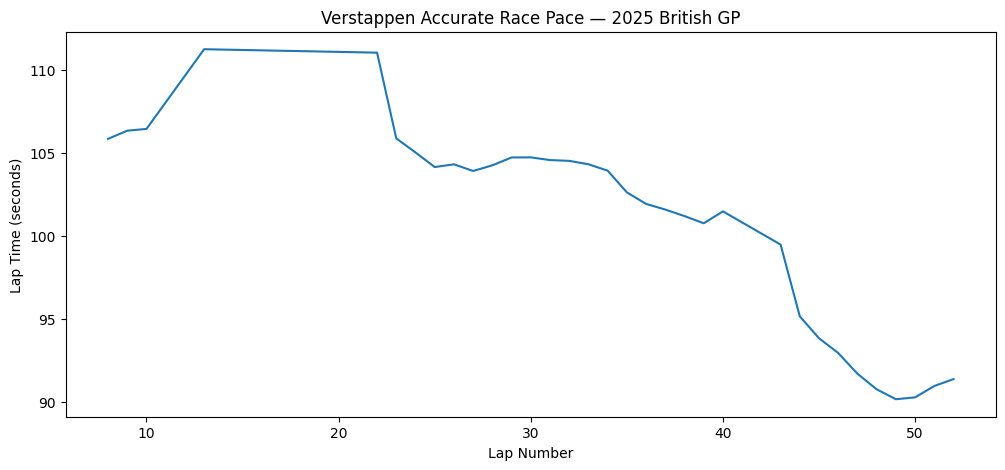

In [114]:
plt.figure(figsize=(12, 5))

plt.plot(
    ver_pace["LapNumber"],
    ver_pace["LapTimeSeconds"]
)

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Verstappen Accurate Race Pace — 2025 British GP")

plt.show()

In [115]:
laps["LapTimeSeconds"] = (
    laps["LapTime"]
    .dt.total_seconds()
)

accurate_laps = laps[
    (laps["IsAccurate"] == True) &
    (laps["LapTimeSeconds"].notna())
].copy()

accurate_laps["RacePhase"] = pd.cut(
    accurate_laps["LapNumber"],
    bins=[0, 10, 20, 30, 40, 60],
    labels=[
        "Laps 1–10",
        "Laps 11–20",
        "Laps 21–30",
        "Laps 31–40",
        "Laps 41–60"
    ]
)

phase_pace = (
    accurate_laps
    .groupby("RacePhase", observed=True)["LapTimeSeconds"]
    .median()
)

print(phase_pace)

RacePhase
Laps 1–10     106.4260
Laps 11–20    108.3390
Laps 21–30    104.2840
Laps 31–40    102.9655
Laps 41–60     91.9000
Name: LapTimeSeconds, dtype: float64


In [116]:
strategy_summary = (
    stint_summary
    .groupby("Driver")
    .agg(
        Stints=("Stint", "count"),
        TotalTyreLaps=("Laps", "sum"),
        CompoundsUsed=("Compound", "nunique")
    )
)

print(strategy_summary.sort_values("Stints", ascending=False))

        Stints  TotalTyreLaps  CompoundsUsed
Driver                                      
ANT          4             23              2
STR          4             52              2
ALB          3             52              2
ALO          3             52              2
BEA          3             52              3
HUL          3             52              2
GAS          3             52              2
LEC          3             52              3
PIA          3             52              2
NOR          3             52              2
HAM          3             52              2
RUS          3             52              2
SAI          3             52              2
TSU          3             51              2
OCO          3             52              2
VER          3             52              2
HAD          2             18              2
LAW          1              1              1
BOR          1              4              1


In [118]:
race_results = pd.read_csv(
    "../data/raw/race_results/british_gp_2025.csv"
)

print(race_results.shape)

race_result = race_results[
    [
        "Abbreviation",
        "Position",
        "Points",
        "Status"
    ]
].copy()

strategy_summary = strategy_summary.reset_index()

strategy_summary = strategy_summary.merge(
    race_result,
    left_on="Driver",
    right_on="Abbreviation",
    how="left"
)

print(strategy_summary)

(20, 22)
   Driver  Stints  TotalTyreLaps  CompoundsUsed Abbreviation  Position  \
0     ALB       3             52              2          ALB       8.0   
1     ALO       3             52              2          ALO       9.0   
2     ANT       4             23              2          ANT      16.0   
3     BEA       3             52              3          BEA      11.0   
4     BOR       1              4              1          BOR      18.0   
5     GAS       3             52              2          GAS       6.0   
6     HAD       2             18              2          HAD      17.0   
7     HAM       3             52              2          HAM       4.0   
8     HUL       3             52              2          HUL       3.0   
9     LAW       1              1              1          LAW      19.0   
10    LEC       3             52              3          LEC      14.0   
11    NOR       3             52              2          NOR       1.0   
12    OCO       3            